In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.environ["GROQ_API_KEY"]
llm = ChatGroq(model=os.getenv("QWEN_MODEL"))

In [2]:
llm.invoke("test line")

AIMessage(content='<think>\nOkay, the user wrote "test line." Let me think about how to respond. They might just be checking if the system is working, or maybe they want to see a sample response. I should keep it friendly and open-ended. Maybe ask how I can assist them further. Let me make sure the response is welcoming and encourages them to ask more if needed.\n</think>\n\nHello! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know! 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 10, 'total_tokens': 118, 'completion_time': 0.213163704, 'prompt_time': 0.000244835, 'queue_time': 0.050499355, 'total_time': 0.213408539}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_f17c2eb555', 'finish_reason': 'stop', 'logprobs': None}, id='run--1c8f5410-e237-49c8-991a-3738362c8cdd-0', usage_metadata={'input_tokens': 10, 'output_tokens': 108, 'total_tokens': 118})

# **Custom logic to Build Human in The Loop**

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

In [6]:
@tool
def multiply(a: int, b: int) -> int:
    """This is multiply function"""
    
    return a * b

In [14]:
@tool
def search(query: str):
    "Search the wrb for a query and return the results"
    tavily = TavilySearchResults()
    result = tavily.invoke(query)
    
    return f"Result for {query} is: \n{result}"

response = search.invoke(
    {
        "query": "What is the capital of bangladesh?"
    }
)
response

'Result for What is the capital of bangladesh? is: \n[{\'title\': \'Dhaka - Wikipedia\', \'url\': \'https://en.wikipedia.org/wiki/Dhaka\', \'content\': \'Wikimedia Commons\\n   Wikinews\\n   Wikiquote\\n   Wikivoyage\\n   Wikidata item\\n\\nCoordinates: Image 423°48′15″N 90°24′55″E / 23.80417°N 90.41528°E / 23.80417; 90.41528)\\n\\nFrom Wikipedia, the free encyclopedia\\n\\nCapital and largest city of Bangladesh\\n\\nThis article is about the capital city. For the division, see Dhaka Division. For the district, see Dhaka District. For other uses, see Dhaka (disambiguation) "Dhaka (disambiguation)").\\n\\nNot to be confused with Senegal\\\'s capital city Dakar. [...] As the capital of the People\\\'s Republic of Bangladesh, Dhaka is home to numerous state and diplomatic institutions. The Bangabhaban is the official residence and workplace of the President of Bangladesh, who is the ceremonial head of state under the constitution. The National Parliament House is located in the modernist 

In [8]:
tools = [multiply, search]
tools

[StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001F537640400>),
 StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001F537642200>)]

In [9]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [10]:
tool_mapping = {tool.name:tool for tool in tools}
tool_mapping

{'multiply': StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001F537640400>),
 'search': StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001F537642200>)}

In [11]:
tool_mapping["search"]

StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x000001F537642200>)

In [13]:
tool_mapping["search"].invoke(
    {
        "query": "who is dr. yunus?"
    }
)

'Result for who is dr. yunus? is: \n[{\'title\': \'Founder - Grameen Bank\', \'url\': \'https://grameenbank.org.bd/about/founder\', \'content\': "Dr. Muhammad Yunus, a distinguished Bangladeshi entrepreneur, banker, economist, and civil society leader, remains a prominent global figure known for his pioneering work in microfinance and social business. Born on June 28, 1940, Yunus has made significant contributions to economic development and poverty alleviation through his innovative approach to financial inclusion. As of August 2024, Yunus holds the esteemed position of Chief Adviser to the interim government of Bangladesh, a role he [...] #### Recent Developments\\n\\nIn August 2024, Dr. Yunus was appointed as the Chief Adviser to the interim government of Bangladesh following the dissolution of parliament and the resignation of former Prime Minister Sheikh Hasina. His appointment was influenced by students\' demands and was facilitated by his acquittal of charges related to labor co

In [17]:
response = llm_with_tools.invoke("what is the current weather in bangladesh.")

In [18]:
tool_mapping[response.tool_calls[0]["name"]].invoke(response.tool_calls[0]["args"])

"Result for current weather in bangladesh is: \n[{'title': 'Dhaka June 2025 Historical Weather Data (Bangladesh)', 'url': 'https://weatherspark.com/h/m/111858/2025/6/Historical-Weather-in-June-2025-in-Dhaka-Bangladesh', 'content': 'Latest Report — 4:00 PM ; Temp. 82°F ; Wind. 11.5 mph ; Cloud Cover. Mostly Cloudy 1,200 ft', 'score': 0.87782305}, {'title': 'Weather in Bangladesh in June 2025 - Detailed Forecast', 'url': 'https://www.easeweather.com/asia/bangladesh/june', 'content': 'easeweather.com\\nBangladesh weather\\n\\n# Weather in Bangladesh for June 2025\\n\\n### Temperatures\\n\\nUntil now, June 2025 in Bangladesh is slightly cooler than the historical average by -1.4 °C.\\n\\nThe forecast for the next days in Bangladesh predicts temperatures to be around 32 °C, close to the historical average. [...] Patchy rain possible\\nPatchy rain possible\\nSunny\\nSunny\\nSunny\\nModerate rain at times\\nSunny\\nModerate or heavy rain shower\\nModerate or heavy rain shower\\nModerate or he

## **Now Build the Graph**

In [19]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import BaseMessage

In [20]:
class AgentState(TypedDict):
    """State for the agent."""
    messages: Annotated[Sequence[BaseMessage],operator.add]

In [21]:
def invoke_model(state:AgentState):
    pass

In [ ]:
def router(state: AgentState):
    pass

In [22]:
def invoke_tool(state:AgentState):
    pass

- eariler we were using the tool node from list of tool

- but now we have crate tool invoke(custom funtion)

- why we are doing it: as a user if we want to take a authority to which i need to give permission for execution

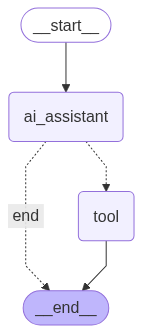

In [26]:
from langgraph.graph import StateGraph, START,END
graph=StateGraph(AgentState)

graph.add_node("ai_assistant", invoke_model)
graph.add_node("tool", invoke_tool)

graph.add_conditional_edges("ai_assistant",
                            router,
                            {
                                "tool":"tool",
                                "end":END
                            }
                            )
graph.add_edge("tool", END)

graph.set_entry_point("ai_assistant")
graph.compile()